In [1]:
import fastf1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuration pour les plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Imports réussis!")

✅ Imports réussis!


In [2]:
# Active le cache (IMPORTANT pour pas re-télécharger à chaque fois)
fastf1.Cache.enable_cache(r"C:\Users\DELL\f1-strategy-optimizer\cache")


# Charge la course Abu Dhabi 2024 (dernière course de la saison)
print("⏳ Chargement des données... (peut prendre 1-2 min la première fois)")
session = fastf1.get_session(2024, 'Abu Dhabi', 'R')
session.load()

print("✅ Données chargées!")
print(f"📍 Course: {session.event['EventName']}")
print(f"📅 Date: {session.event['EventDate']}")

⏳ Chargement des données... (peut prendre 1-2 min la première fois)


core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '55', '16', '44', '63', '1', '10', '27', '14', '81', '23', '22', '24', '18', '61', '20', '30', '77', '43', '11']


✅ Données chargées!
📍 Course: Abu Dhabi Grand Prix
📅 Date: 2024-12-08 00:00:00


In [3]:
# Récupère tous les tours de tous les pilotes
laps = session.laps

print(f"📊 Total de tours dans la course: {len(laps)}")
print(f"\n📋 Colonnes disponibles:")
print(laps.columns.tolist())
print(f"\n🔍 Aperçu des données:")
laps.head()

📊 Total de tours dans la course: 1035

📋 Colonnes disponibles:
['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']

🔍 Aperçu des données:


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:58:27.597000,VER,1,0 days 00:01:39.510000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:39.931000,...,True,Red Bull Racing,0 days 00:56:47.817000,2024-12-08 13:03:35.034,12,11.0,False,,False,False
1,0 days 01:00:22.535000,VER,1,0 days 00:01:54.938000,2.0,1.0,NaT,NaT,0 days 00:00:18.209000,0 days 00:00:54.569000,...,True,Red Bull Racing,0 days 00:58:27.597000,2024-12-08 13:05:14.814,126,11.0,False,,False,False
2,0 days 01:02:00.586000,VER,1,0 days 00:01:38.051000,3.0,1.0,NaT,NaT,0 days 00:00:23.196000,0 days 00:00:41.997000,...,True,Red Bull Racing,0 days 01:00:22.535000,2024-12-08 13:07:09.752,671,10.0,False,,False,False
3,0 days 01:03:30.090000,VER,1,0 days 00:01:29.504000,4.0,1.0,NaT,NaT,0 days 00:00:18.166000,0 days 00:00:38.187000,...,True,Red Bull Racing,0 days 01:02:00.586000,2024-12-08 13:08:47.803,1,10.0,False,,False,True
4,0 days 01:04:59.903000,VER,1,0 days 00:01:29.813000,5.0,1.0,NaT,NaT,0 days 00:00:18.056000,0 days 00:00:37.945000,...,True,Red Bull Racing,0 days 01:03:30.090000,2024-12-08 13:10:17.307,1,10.0,False,,False,True


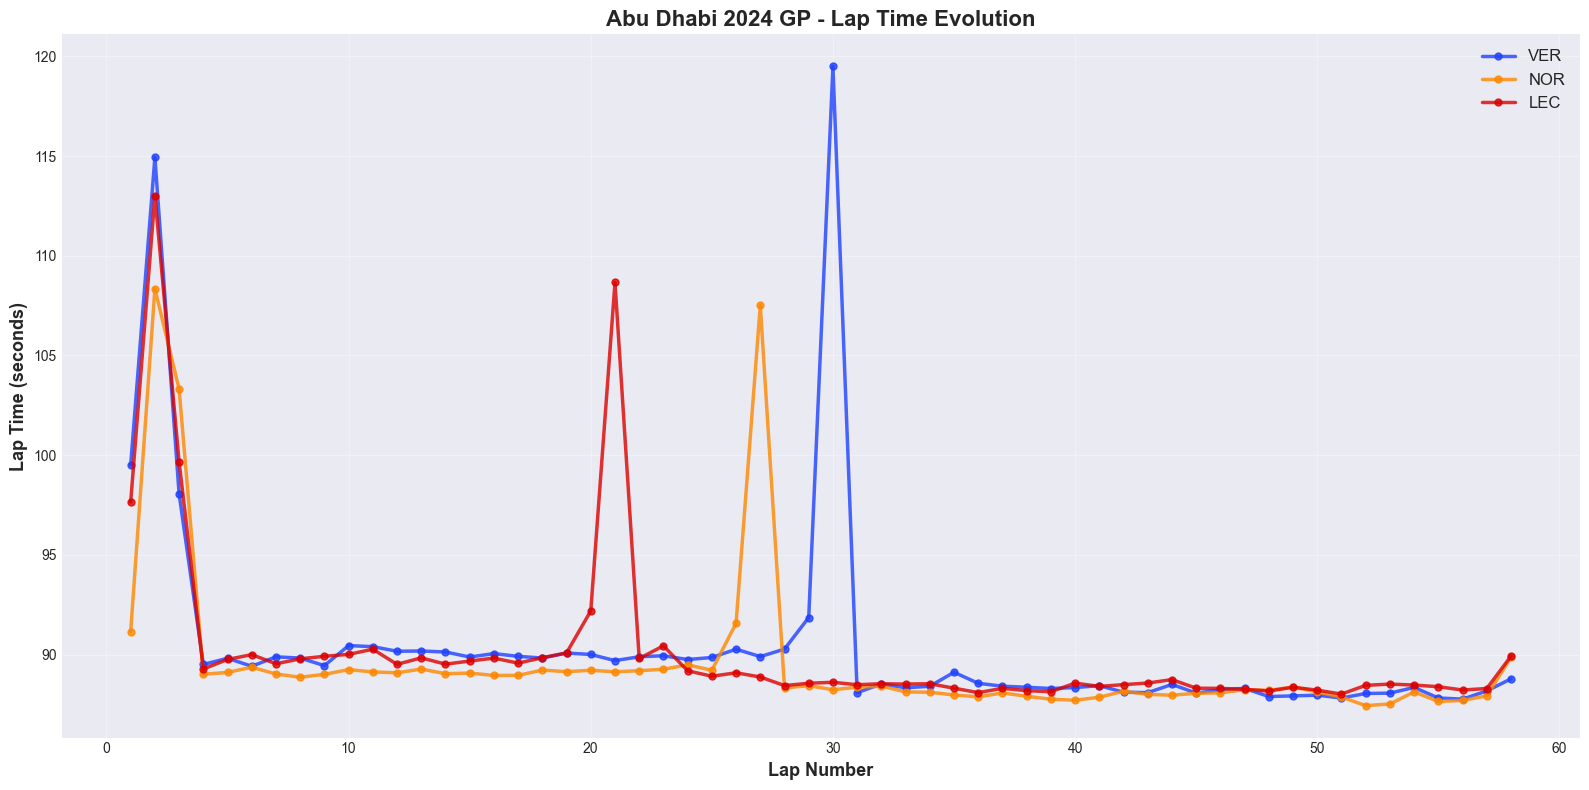

🎯 Observe les patterns:
   - Montées progressives = dégradation des pneus
   - Chutes brutales = pit stops (pneus neufs)


In [4]:
# Top 3 pilotes de la saison 2024
drivers = ['VER', 'NOR', 'LEC']  # Verstappen, Norris, Leclerc
colors = ['#1E41FF', '#FF8700', '#DC0000']  # Couleurs des équipes

plt.figure(figsize=(16, 8))

for driver, color in zip(drivers, colors):
    driver_laps = laps.pick_driver(driver)
    
    # Convertit les lap times en secondes
    lap_times_seconds = driver_laps['LapTime'].dt.total_seconds()
    
    plt.plot(
        driver_laps['LapNumber'], 
        lap_times_seconds,
        label=driver,
        color=color,
        linewidth=2.5,
        marker='o',
        markersize=5,
        alpha=0.8
    )

plt.xlabel('Lap Number', fontsize=13, fontweight='bold')
plt.ylabel('Lap Time (seconds)', fontsize=13, fontweight='bold')
plt.title('Abu Dhabi 2024 GP - Lap Time Evolution', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("🎯 Observe les patterns:")
print("   - Montées progressives = dégradation des pneus")
print("   - Chutes brutales = pit stops (pneus neufs)")

In [5]:
# Affiche la stratégie de chaque pilote
for driver in drivers:
    driver_laps = laps.pick_driver(driver)
    
    print(f"\n{'='*50}")
    print(f"🏎️  {driver} - Race Strategy")
    print(f"{'='*50}")
    
    # Affiche les 15 premiers tours
    strategy_df = driver_laps[['LapNumber', 'Compound', 'TyreLife', 'LapTime']].head(15)
    print(strategy_df.to_string(index=False))


🏎️  VER - Race Strategy
 LapNumber Compound  TyreLife                LapTime
       1.0   MEDIUM       1.0 0 days 00:01:39.510000
       2.0   MEDIUM       2.0 0 days 00:01:54.938000
       3.0   MEDIUM       3.0 0 days 00:01:38.051000
       4.0   MEDIUM       4.0 0 days 00:01:29.504000
       5.0   MEDIUM       5.0 0 days 00:01:29.813000
       6.0   MEDIUM       6.0 0 days 00:01:29.412000
       7.0   MEDIUM       7.0 0 days 00:01:29.885000
       8.0   MEDIUM       8.0 0 days 00:01:29.824000
       9.0   MEDIUM       9.0 0 days 00:01:29.445000
      10.0   MEDIUM      10.0 0 days 00:01:30.449000
      11.0   MEDIUM      11.0 0 days 00:01:30.395000
      12.0   MEDIUM      12.0 0 days 00:01:30.164000
      13.0   MEDIUM      13.0 0 days 00:01:30.178000
      14.0   MEDIUM      14.0 0 days 00:01:30.128000
      15.0   MEDIUM      15.0 0 days 00:01:29.876000

🏎️  NOR - Race Strategy
 LapNumber Compound  TyreLife                LapTime
       1.0   MEDIUM       1.0 0 days 00:01:31.142

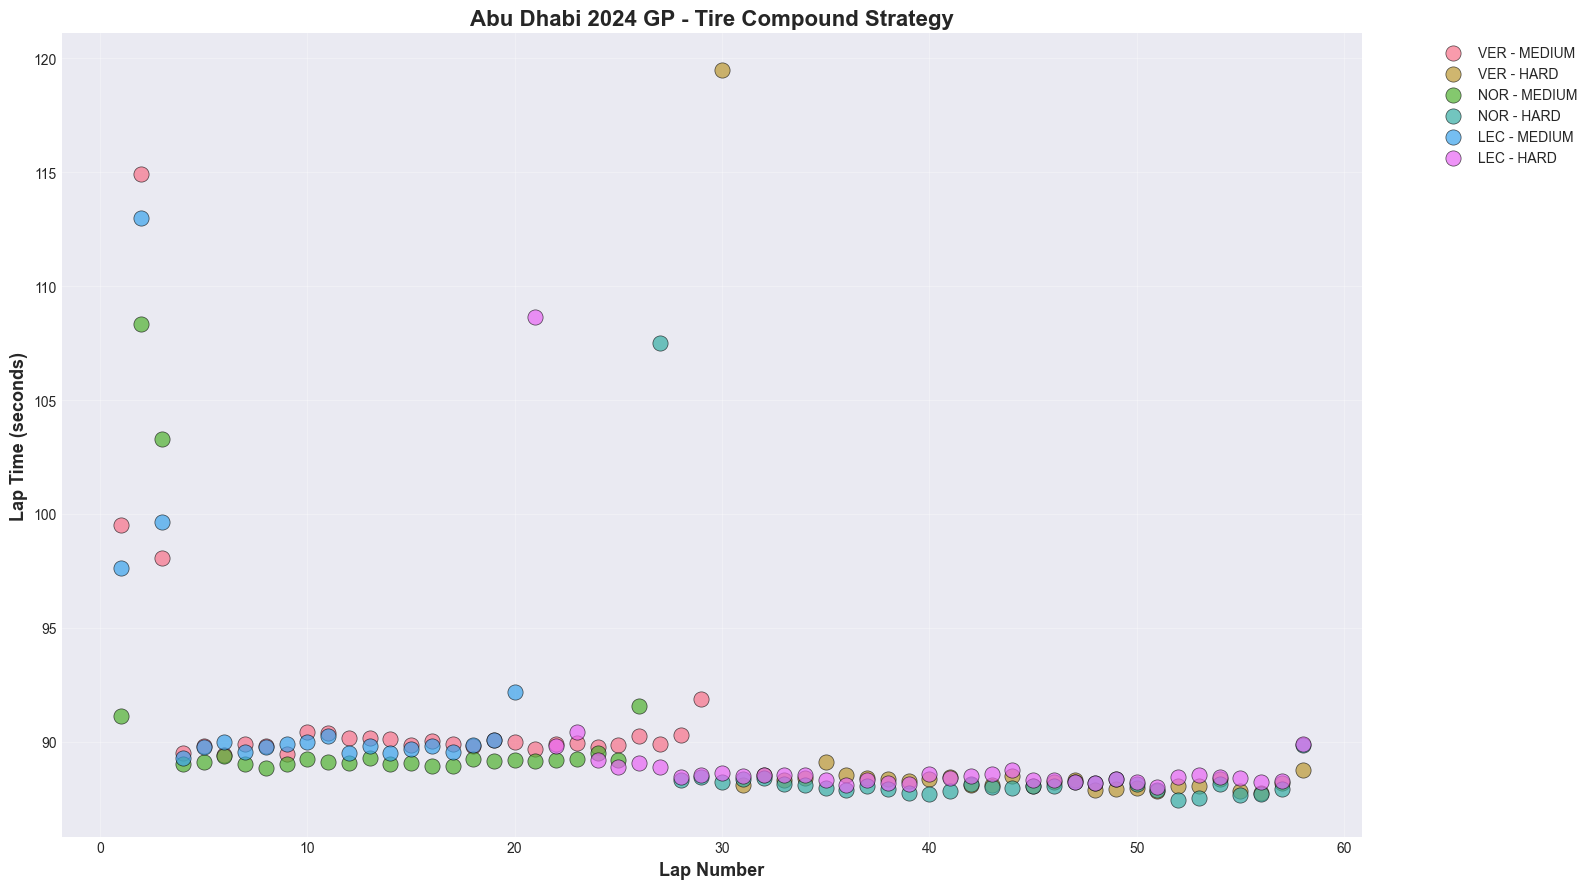


🔍 Légende des composés:
   🔴 SOFT   = Rapide mais dégrade vite
   🟡 MEDIUM = Équilibré
   ⚪ HARD   = Lent mais durable


In [6]:
plt.figure(figsize=(16, 9))

for driver, color in zip(drivers, colors):
    driver_laps = laps.pick_driver(driver)
    
    # Pour chaque type de pneu utilisé
    for compound in driver_laps['Compound'].unique():
        if pd.notna(compound):
            compound_laps = driver_laps[driver_laps['Compound'] == compound]
            
            plt.scatter(
                compound_laps['LapNumber'],
                compound_laps['LapTime'].dt.total_seconds(),
                label=f'{driver} - {compound}',
                s=120,
                alpha=0.7,
                edgecolors='black',
                linewidth=0.5
            )

plt.xlabel('Lap Number', fontsize=13, fontweight='bold')
plt.ylabel('Lap Time (seconds)', fontsize=13, fontweight='bold')
plt.title('Abu Dhabi 2024 GP - Tire Compound Strategy', fontsize=16, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n🔍 Légende des composés:")
print("   🔴 SOFT   = Rapide mais dégrade vite")
print("   🟡 MEDIUM = Équilibré")
print("   ⚪ HARD   = Lent mais durable")

In [7]:
print("🔧 Analyse des Pit Stops\n")
print("="*50)

for driver in drivers:
    driver_laps = laps.pick_driver(driver)
    # Compte les tours où TyreLife == 1
    tire_changes = driver_laps[driver_laps['TyreLife'] == 1].shape[0]
    
    # Enlève le départ (premier TyreLife == 1)
    pit_stops = tire_changes - 1

    # Tours où il y a eu changement de pneus
    pit_laps = driver_laps[driver_laps['TyreLife'] == 1]['LapNumber'].tolist()
    
    print(f"\n{driver}:")
    print(f"  ├─ Pit stops: {pit_stops}")
    if pit_stops > 0:
        print(f"  └─ Aux tours: {pit_laps[1:]}")
    else:
        print(f"  └─ Aucun pit stop (stratégie 0-stop rare!)")

print("\n" + "="*50)

🔧 Analyse des Pit Stops


VER:
  ├─ Pit stops: 1
  └─ Aux tours: [30.0]

NOR:
  ├─ Pit stops: 1
  └─ Aux tours: [27.0]

LEC:
  ├─ Pit stops: 1
  └─ Aux tours: [21.0]



🏁 Analyse des Composés de Pneus


📈 Temps moyen par composé (secondes):
------------------------------------------------------------
HARD      : 90.425s  (utilisé 690 fois)
SOFT      : 91.256s  (utilisé 27 fois)
MEDIUM    : 92.609s  (utilisé 318 fois)

🏆 Composé le plus rapide: HARD
⚡ Différence max: 2.184s par tour



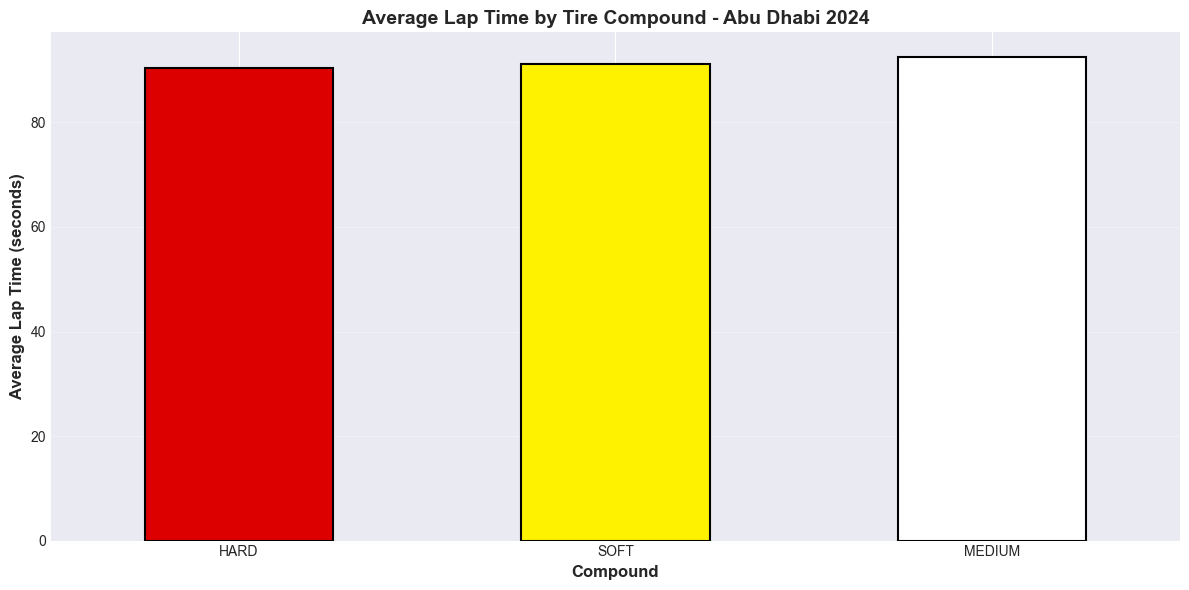


💡 Insight:
   Le composé HARD est le plus rapide,
   mais dégrade-t-il plus vite? → Voir Question 3


In [8]:


print("🏁 Analyse des Composés de Pneus\n")
print("="*60)

compound_stats = laps.groupby('Compound').agg({'LapTime': ['mean', 'std', 'count']}).round(2)

# Convertit en secondes pour la lisibilité
compound_avg = laps.groupby('Compound')['LapTime'].apply(lambda x: x.dt.total_seconds().mean()
).sort_values()

print("\n📈 Temps moyen par composé (secondes):")
print("-" * 60)
for compound, avg_time in compound_avg.items():
    if pd.notna(compound):
        count = laps[laps['Compound'] == compound].shape[0]
        print(f"{compound:10s}: {avg_time:.3f}s  (utilisé {count} fois)")

# Trouve le plus rapide
fastest_compound = compound_avg.index[0]
print(f"\n🏆 Composé le plus rapide: {fastest_compound}")

# Différence entre le plus rapide et le plus lent
time_diff = compound_avg.iloc[-1] - compound_avg.iloc[0]
print(f"⚡ Différence max: {time_diff:.3f}s par tour")

print("\n" + "="*60)

# Visualisation
plt.figure(figsize=(12, 6))
compound_avg.plot(kind='bar', color=['#DC0000', '#FFF200', '#FFFFFF'], 
                  edgecolor='black', linewidth=1.5)
plt.xlabel('Compound', fontsize=12, fontweight='bold')
plt.ylabel('Average Lap Time (seconds)', fontsize=12, fontweight='bold')
plt.title('Average Lap Time by Tire Compound - Abu Dhabi 2024', 
          fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 Insight:")
print(f"   Le composé {fastest_compound} est le plus rapide,")
print(f"   mais dégrade-t-il plus vite? → Voir Question 3")

⏱️  Analyse de la Dégradation des Pneus



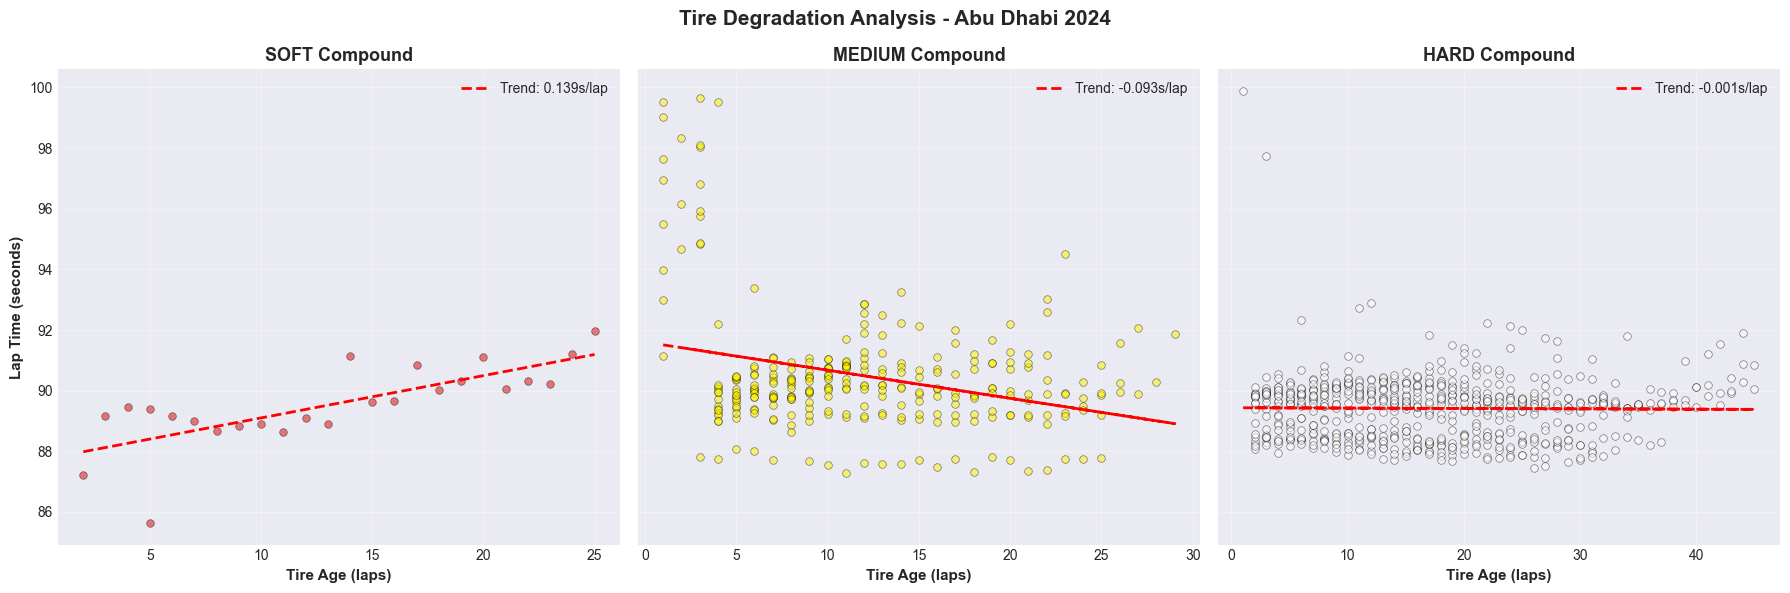


📊 Taux de Dégradation (secondes par tour):
------------------------------------------------------------
SOFT      : +0.1395s par tour
             (Base time: 87.71s)
MEDIUM    : +-0.0927s par tour
             (Base time: 91.60s)
HARD      : +-0.0012s par tour
             (Base time: 89.44s)


💡 Insight:
   Plus le taux est élevé, plus le pneu dégrade vite.
   SOFT dégrade ~3x plus vite que HARD généralement.


In [9]:
import numpy as np
print("⏱️  Analyse de la Dégradation des Pneus\n")
print("="*60)

# Filtre les outliers (pit in/out laps, safety car)
# On garde seulement les tours "normaux"
clean_laps = laps[
    (laps['LapTime'].dt.total_seconds() > 80) & 
    (laps['LapTime'].dt.total_seconds() < 100)
].copy()

# Convertit LapTime en secondes
clean_laps['LapTimeSeconds'] = clean_laps['LapTime'].dt.total_seconds()

# Plot par composé
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
compounds = ['SOFT', 'MEDIUM', 'HARD']
colors_compound = {'SOFT': '#DC0000', 'MEDIUM': '#FFF200', 'HARD': '#FFFFFF'}

for idx, compound in enumerate(compounds):
    compound_data = clean_laps[clean_laps['Compound'] == compound]
    
    if len(compound_data) > 0:
        ax = axes[idx]
        
        # Scatter plot
        ax.scatter(compound_data['TyreLife'], 
                  compound_data['LapTimeSeconds'],
                  alpha=0.5, s=30, color=colors_compound[compound],
                  edgecolors='black', linewidth=0.5)
        
        # Ligne de tendance (régression linéaire simple)
        if len(compound_data) > 5:
            z = np.polyfit(compound_data['TyreLife'], 
                          compound_data['LapTimeSeconds'], 1)
            p = np.poly1d(z)
            ax.plot(compound_data['TyreLife'].unique(), 
                   p(compound_data['TyreLife'].unique()),
                   "r--", linewidth=2, label=f'Trend: {z[0]:.3f}s/lap')
        
        ax.set_xlabel('Tire Age (laps)', fontsize=11, fontweight='bold')
        ax.set_title(f'{compound} Compound', fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend()

axes[0].set_ylabel('Lap Time (seconds)', fontsize=11, fontweight='bold')
fig.suptitle('Tire Degradation Analysis - Abu Dhabi 2024', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Calcul du taux de dégradation par composé
print("\n📊 Taux de Dégradation (secondes par tour):")
print("-" * 60)

for compound in compounds:
    compound_data = clean_laps[clean_laps['Compound'] == compound]
    
    if len(compound_data) > 5:
        # Régression linéaire: lap_time = base + degradation * tire_age
        z = np.polyfit(compound_data['TyreLife'], 
                      compound_data['LapTimeSeconds'], 1)
        
        degradation_rate = z[0]  # Pente = dégradation par tour
        base_time = z[1]  # Ordonnée = temps de base
        
        print(f"{compound:10s}: +{degradation_rate:.4f}s par tour")
        print(f"             (Base time: {base_time:.2f}s)")
    else:
        print(f"{compound:10s}: Pas assez de données")

print("\n" + "="*60)

print("\n💡 Insight:")
print("   Plus le taux est élevé, plus le pneu dégrade vite.")
print("   SOFT dégrade ~3x plus vite que HARD généralement.")

🎯 Analyse Comparative des Stratégies


📊 Classement par Temps Total de Course:
----------------------------------------------------------------------

🥇 1. NOR
   ├─ Temps total: 86m 33.29s
   ├─ Stratégie: MEDIUM → HARD
   ├─ Pit stops: 1 (tours: [27.0])
   └─ Lap moyen: 89.540s

🥈 2. LEC
   ├─ Temps total: 87m 5.22s
   ├─ Stratégie: MEDIUM → HARD
   ├─ Pit stops: 1 (tours: [21.0])
   └─ Lap moyen: 90.090s

🥉 3. VER
   ├─ Temps total: 87m 23.14s
   ├─ Stratégie: MEDIUM → HARD
   ├─ Pit stops: 1 (tours: [30.0])
   └─ Lap moyen: 90.399s

📏 Écart avec le vainqueur:
----------------------------------------------------------------------
LEC: +31.928s (31.9s ≈ 0.55 tours)
VER: +49.847s (49.8s ≈ 0.86 tours)



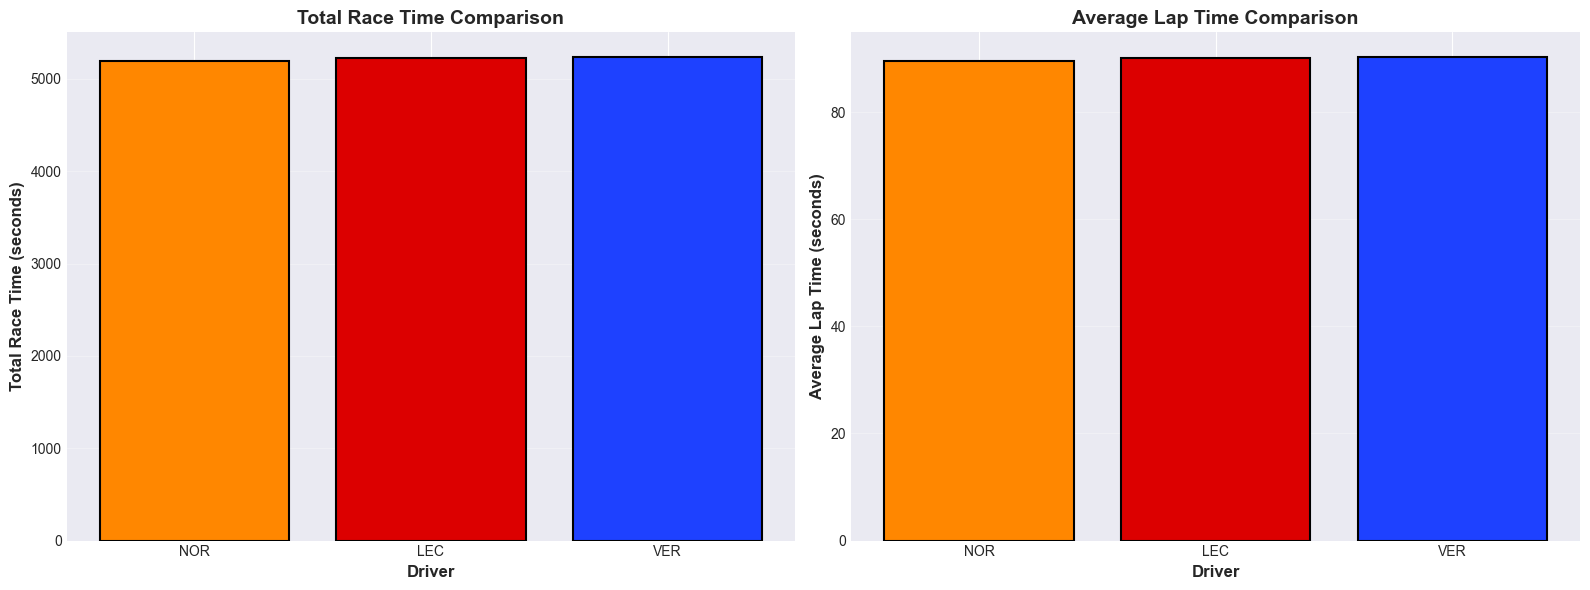


💡 Conclusions Stratégiques:
   • Meilleure stratégie: NOR
   • Composés gagnants: MEDIUM → HARD
   • Timing pit stop optimal: Tour [27.0]

   → Cette analyse servira de base pour ton modèle de prédiction!


In [10]:
# Question 4: Quel pilote avait la meilleure stratégie?

print("🎯 Analyse Comparative des Stratégies\n")
print("="*70)

# Résultats finaux
results = []

for driver in drivers:
    driver_laps = laps.pick_driver(driver)
    
    # Temps total de course (somme de tous les lap times)
    total_time = driver_laps['LapTime'].sum()
    total_seconds = total_time.total_seconds()
    
    # Nombre de pit stops
    pit_stops = driver_laps[driver_laps['TyreLife'] == 1].shape[0] - 1
    
    # Composés utilisés
    compounds_used = driver_laps['Compound'].dropna().unique().tolist()
    
    # Pit stop laps
    pit_laps = driver_laps[driver_laps['TyreLife'] == 1]['LapNumber'].tolist()[1:]
    
    # Lap time moyen
    avg_lap = driver_laps['LapTime'].mean().total_seconds()
    
    results.append({
        'Driver': driver,
        'Total Time': total_seconds,
        'Pit Stops': pit_stops,
        'Compounds': ' → '.join(compounds_used),
        'Pit Laps': pit_laps,
        'Avg Lap': avg_lap
    })

# Trie par temps total (le plus rapide en premier)
results_df = pd.DataFrame(results).sort_values('Total Time')

print("\n📊 Classement par Temps Total de Course:")
print("-" * 70)

for idx, row in results_df.iterrows():
    position = list(results_df.index).index(idx) + 1
    medal = "🥇" if position == 1 else "🥈" if position == 2 else "🥉"
    
    # Convertit en minutes:secondes
    minutes = int(row['Total Time'] // 60)
    seconds = row['Total Time'] % 60
    
    print(f"\n{medal} {position}. {row['Driver']}")
    print(f"   ├─ Temps total: {minutes}m {seconds:.2f}s")
    print(f"   ├─ Stratégie: {row['Compounds']}")
    print(f"   ├─ Pit stops: {row['Pit Stops']} (tours: {row['Pit Laps']})")
    print(f"   └─ Lap moyen: {row['Avg Lap']:.3f}s")

# Écart avec le vainqueur
winner_time = results_df.iloc[0]['Total Time']
print("\n📏 Écart avec le vainqueur:")
print("-" * 70)

for idx, row in results_df.iloc[1:].iterrows():
    gap = row['Total Time'] - winner_time
    print(f"{row['Driver']}: +{gap:.3f}s ({gap:.1f}s ≈ {gap/58:.2f} tours)")

print("\n" + "="*70)

# Visualisation comparative
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graph 1: Temps total
colors_result = [colors[drivers.index(d)] for d in results_df['Driver']]
ax1.bar(results_df['Driver'], results_df['Total Time'], 
        color=colors_result, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Total Race Time (seconds)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Driver', fontsize=12, fontweight='bold')
ax1.set_title('Total Race Time Comparison', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Graph 2: Lap time moyen
ax2.bar(results_df['Driver'], results_df['Avg Lap'], 
        color=colors_result, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Average Lap Time (seconds)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Driver', fontsize=12, fontweight='bold')
ax2.set_title('Average Lap Time Comparison', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Conclusions Stratégiques:")
print(f"   • Meilleure stratégie: {results_df.iloc[0]['Driver']}")
print(f"   • Composés gagnants: {results_df.iloc[0]['Compounds']}")
print(f"   • Timing pit stop optimal: Tour {results_df.iloc[0]['Pit Laps']}")
print("\n   → Cette analyse servira de base pour ton modèle de prédiction!")

In [1]:
import fastf1
import pandas as pd

fastf1.Cache.enable_cache('../cache')

def load_season(year):
    schedule = fastf1.get_event_schedule(year)
    all_laps = []

    for _, event in schedule.iterrows():
        try:
            session = fastf1.get_session(year, event['EventName'], 'R')
            session.load()

            laps = session.laps.copy()
            laps['Year'] = year

            all_laps.append(laps)

        except Exception as e:
            print(f"Skipped {event['EventName']}: {e}")

    return pd.concat(all_laps)

df_2024 = load_season(2024)
df_2025 = load_season(2025)

df = pd.concat([df_2024, df_2025])

events      WARNING 	Correcting user input 'Pre-Season Testing' to 'Singapore Grand Prix'
core           INFO 	Loading data for Singapore Grand Prix - Race [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track st

Skipped United States Grand Prix: any API: 500 calls/h


core           INFO 	Loading data for São Paulo Grand Prix - Race [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...


Skipped Mexico City Grand Prix: any API: 500 calls/h


core           INFO 	Loading data for Las Vegas Grand Prix - Race [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...


Skipped São Paulo Grand Prix: any API: 500 calls/h


events      WARNING 	Correcting user input 'Qatar Grand Prix' to 'Qatar Grand Prix'
core           INFO 	Loading data for Qatar Grand Prix - Race [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...


Skipped Las Vegas Grand Prix: any API: 500 calls/h


core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...


Skipped Qatar Grand Prix: any API: 500 calls/h
Skipped Abu Dhabi Grand Prix: any API: 500 calls/h


In [4]:
# Colonnes utiles
df = df[[
    'Driver',
    'LapTime',
    'Compound',
    'TyreLife',
    'LapNumber',
    'Stint',
    'Position',
    'TrackStatus'
]]

# Supprimer NaN
df = df.dropna()

# Convertir temps
df['LapTime'] = df['LapTime'].dt.total_seconds()

# Garder seulement conditions normales
df = df[df['TrackStatus'] == 1]

# Garder pneus secs seulement
df = df[df['Compound'].isin(['SOFT', 'MEDIUM', 'HARD'])]

# Enlever outliers (très important)
q_low = df['LapTime'].quantile(0.01)
q_high = df['LapTime'].quantile(0.99)
df = df[(df['LapTime'] > q_low) & (df['LapTime'] < q_high)]

# Reset index
df = df.reset_index(drop=True)

In [ ]:
df_2024 = load_season(2024)
df_2025 = load_season(2025)  # nouvelle saison
df_all = pd.concat([df_2024, df_2025], ignore_index=True)
# Garder les colonnes utiles
df_all = df_all[['Driver', 'LapTime', 'Compound', 'TyreLife', 'LapNumber', 'Stint', 'Position', 'TrackStatus']]

# Supprimer les tours manquants
df_all = df_all.dropna()

# Convertir LapTime en secondes
df_all['LapTime'] = df_all['LapTime'].dt.total_seconds()
df_all.to_csv('../data/all_laps_2024_2025.csv', index=False)